# 1. Carga de dataset y modelos:
Lo primero que se hace es importar todos los modelos creados ne el notebook anterior, aunque se indica que solo se trabaje con el mmodelo escogido en el notebook anterior, aquí se presentan ambos:

In [8]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

! cd /content/drive/MyDrive/practica_NPL

path = "/content/drive/MyDrive/practica_NPL"

In [10]:
import pickle

models_path = f"{path}/models"

# Cargar TF-IDF vectorizer
with open(f"{models_path}/tfidf_vectorizer.pkl", "rb") as f:
    cv = pickle.load(f)

# Cargar Logistic Regression
with open(f"{models_path}/logreg_tfidf.pkl", "rb") as f:
    best_lr = pickle.load(f)

# Cargar SVM
with open(f"{models_path}/svm_tfidf.pkl", "rb") as f:
    svm_best = pickle.load(f)

Y como se ha hecho antes, se vectoriza la data:

In [11]:
# Se lee el datset test que es el que nos ayuda a la evaluación final del modelo (aunque ya se hizo anteiormente):
test_df = pd.read_csv(f"{path}/test_df.csv")
train_df = pd.read_csv(f"{path}/train_df.csv")

X_train = train_df["text_preprocessed"]
y_train = train_df["sentiment"]
X_test = test_df["text_preprocessed"]
y_test = test_df["sentiment"]

print("Train:", train_df.shape)
print("test:", test_df.shape)
print(y_test.value_counts())

Train: (3741, 2)
test: (1247, 2)
sentiment
1    624
0    623
Name: count, dtype: int64


In [12]:
X_train_tfidf = cv.transform(X_train)
X_test_tfidf = cv.transform(X_test)

Una vez importados, y preparado el corpus como hicimos en el anterior notebook pasamos a una evaluación un poco más profunda a lo que ya hicimos:

# 2. Evaluación:

## Comparación básica entre ambos modelos:

In [13]:
y_pred_lr = best_lr.predict(X_test_tfidf)
y_pred_svm = svm_best.predict(X_test_tfidf)

In [26]:
# como en el notebook anterior y como se vio en clase:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_curve
import matplotlib.pyplot as plt

print("----------------PARA LOGISTIC REGRESSION----------------")
print('Confussion matrix:\n{}'.format(confusion_matrix(y_test, y_pred_lr)))
print('\nClassification report:\n{}'.format(classification_report(y_test, y_pred_lr,digits=4)))
print('Accuracy score:{}'.format(accuracy_score(y_test, y_pred_lr)))

print("------------------------PARA SVM------------------------")
print('Confussion matrix:\n{}'.format(confusion_matrix(y_test, y_pred_svm)))
print('\nClassification report:\n{}'.format(classification_report(y_test, y_pred_svm, digits=4)))
print('Accuracy score:{}'.format(accuracy_score(y_test, y_pred_svm)))

----------------PARA LOGISTIC REGRESSION----------------
Confussion matrix:
[[518 105]
 [ 97 527]]

Classification report:
              precision    recall  f1-score   support

           0     0.8423    0.8315    0.8368       623
           1     0.8339    0.8446    0.8392       624

    accuracy                         0.8380      1247
   macro avg     0.8381    0.8380    0.8380      1247
weighted avg     0.8381    0.8380    0.8380      1247

Accuracy score:0.8380112269446672
------------------------PARA SVM------------------------
Confussion matrix:
[[523 100]
 [ 96 528]]

Classification report:
              precision    recall  f1-score   support

           0     0.8449    0.8395    0.8422       623
           1     0.8408    0.8462    0.8435       624

    accuracy                         0.8428      1247
   macro avg     0.8428    0.8428    0.8428      1247
weighted avg     0.8428    0.8428    0.8428      1247

Accuracy score:0.842822774659182


ESto ya se comentó anteriormente --> mejor modelo SVM. Ahora además es más claro, pues se ha puesto más digitos para cada valor de la métrica, y no se realiza ningun redondeo que pueda dar pie a confusión.

In [51]:
# para tener un barrido, es decir scores continuos en lugar de preidccions discretas, se utiliza un predict_proba o decision_fuction para nuestra grafica precision-recall
y_pred_lr = best_lr.predict_proba(X_test_tfidf)[:, 1] # se toma la clase positiva, porque precision_recall_curve utiliza por defecto esta clase positiva
y_score_svm = svm_best.decision_function(X_test_tfidf)
p_svm, r_svm, thresholds_svm = precision_recall_curve(y_test, y_pred_svm)
p_lr, r_lr, thresholds_lr = precision_recall_curve(y_test, y_pred_lr)

In [48]:
#COMO EN CLASE:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 8))
    plt.title("Precision and Recall Scores as a function of the decision threshold")
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.ylabel("Score")
    plt.xlabel("Decision Threshold")
    plt.legend(loc='best')

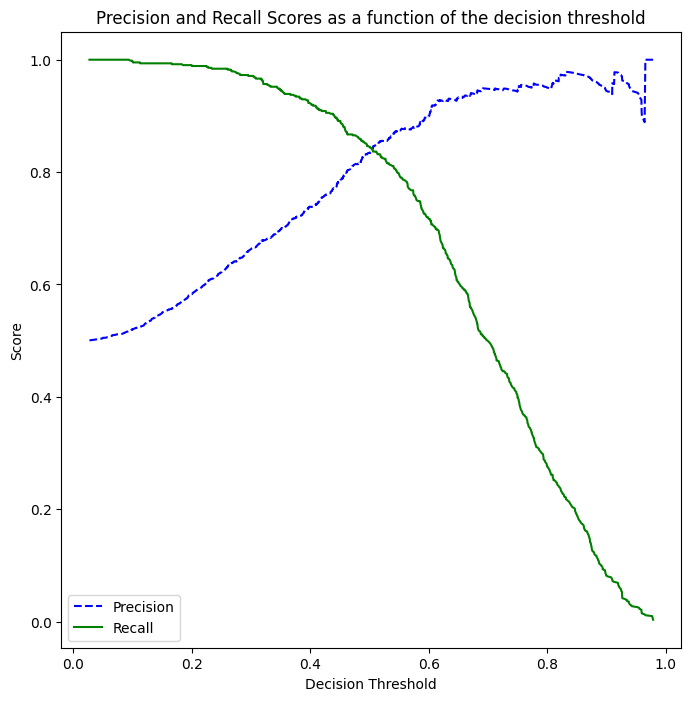

In [52]:
plot_precision_recall_vs_threshold(p_lr, r_lr, thresholds_lr)

La grafica obtenida tiene la forma esperada, segun el eje y que es la probabilidad que tien la muestra de ser de clase 1. En los threshold bajos existe un recall alto (se detectan los positivos). Pus al reecall medir cuantos has podido dectecatr como positivos (verdaderos positivos) de entre todos los que son positivos de verdad, si somos permisivos (threshold bajo) captamos 100% seguros todos los positivos. También la precision es baja, porque al final hay mucho reuido al ser permisivos, esta mide cuanto de todo lo predicho es cierto. Por tanto, cuando el threhols aumenta , sube la precision, lo que se ve en que hay menos falsos positivos, ye l recalll baja pues ya solo detcetas los casos que son muy claros, y se te escapan otros. Por tanto, el punto medio donde se cruzan ambas graficas sería el paaremtro optimo, pues se detcata la mayoria de los positivos y no hay mucha equivocación. Esto me indica que el modleo es bueno.

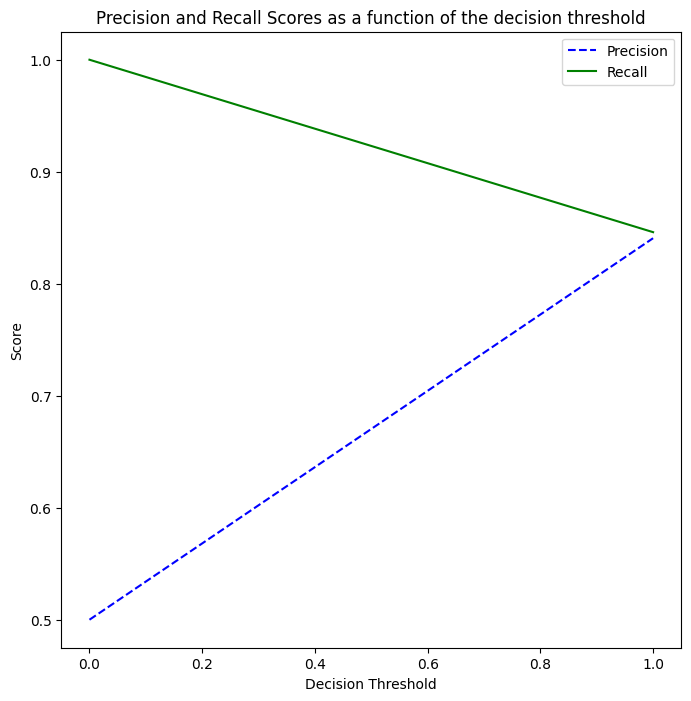

In [49]:
#PARA AHORA EL MODELO SVM:

plot_precision_recall_vs_threshold(p_svm, r_svm, thresholds_svm)

En el caso de la curva para el modelo SVM, vemos una variación más progresiva y limpia que en la anterior, lo que indica que las distancias al hiperplano (en lo que se basa el modelo) se separan de forma proporcional. Aun así, las conclusiones son las mismas como se espera, es decir, cuando somos más permisivos (Umbral bajo) el recall es alto mientras que la precisión es casi nula. Cuando aumentamos el threshold, el recall disminuye, mientras se optimiza la precisión llegando al máximo umbral con una muy buena precision.

Como hicimos en clase, ahora chequemos muestras de forma aleatoria, aunque de forma global se ha visto que funcionan bien ambos métodos:

In [54]:
import random

def predict_review_sentiment(review_index, model):
    print("Actual sentiment: {}".format(y_test.iloc[i]))
    r = X_test.iloc[i]
    print("Review: {}".format(r[:300] + " ..."))
    print("Prediction: {}".format(model.predict(cv.transform([r]))))

print("--------- PARA CASOS LOGISTIC REGRESSION:-----------")
for i in random.sample(range(0, len(X_test)), 5):
    print("\nReview no. {}".format(i))
    predict_review_sentiment(i, best_lr)

print("--------- PARA CASOS SVM:-----------")
for i in random.sample(range(0, len(X_test)), 5):
    print("\nReview no. {}".format(i))
    predict_review_sentiment(i, best_lr)

--------- PARA CASOS LOGISTIC REGRESSION:-----------

Review no. 37
Actual sentiment: 0
Review: although select story interesting book entirety fail caputre attention believe author try make seem writer merely show knowledge classic combine style slam poetry prosody find modern era story excellent narration whilst seem go almost no anyone knowledge classic invent author try publish end result  ...
Prediction: [0]

Review no. 1223
Actual sentiment: 0
Review: horribly predictable human ruin kill whenever whatever include need power ownership prestige still run strong future human sad say one thing find anomalous angered great deal live near florida 's nasa base read science fiction since could read even know man 's great enemy space fire entire habitat d ...
Prediction: [1]

Review no. 489
Actual sentiment: 0
Review: poorly edit autobiography ever read without exception one would think interesting character many child could found someone fix many problem example write autobiography third

Ya para estos 5 casos, se ha visto que hay mas precisión en el SVM, pues ha acertado 4/5 casos.

# 3. Conclusiones:
- Se ha podido ver que ne ambos modelos, el f1-score era igual de alto, lo que es un buen indicador para probelmas de clasificación. En este caso, no como nos pasó en el modulo de DL, frozamos a trabajar con un dtaaset con labels equilibradas, lo que ha suspuesto que las modelos aprendan mejor y no haya valores bajos en sus métricas.
- Asimismo estas métricas a parte de ser buenas para ambos modelos, lo son para ambas clases, pero como se ha dicho, ayuda mucho que el datset esté balanceado.
- Se ha visto que ne le caso de logistic regression el umbral debe estar en el 0.5, pues es donde existe el euilibrio entre recall y precisión.

Como perspectivas, se podría utilizar otro o más dataset de amazon reviews, asi como utilizar más muestras y que estas no estén tan equilibrados, intenatndo retarnos algo más.